In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot
import sys
import seaborn as sns
from tqdm import tqdm
import networkx as nx

import atlasify as atl
from particle import Particle
atl.ATLAS = "ColliderML"

sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/OtherLibraries/pyedm4hep")
from pyedm4hep import EDM4hepEvent, EDM4hepEventBatch

In [29]:
edm_input_file = "/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v1/runs/0/edm4hep.root"
batch = EDM4hepEventBatch(edm_input_file, events=(0, 100), full_load=False)

In [30]:
particles = batch.get_particles_df()

In [31]:
generator_particles = particles[particles["created_in_simulation"] == False]
generator_particles

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,pz,parents_begin,parents_end,vr,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits
0,0,0,2212,0,1.000000,0.000000,0.93827,0.000000,0.000000,0.000000,...,6999.999937,0,0,0.000000,7000.000000,6999.061730,0,False,0,0
1,0,1,1,0,-0.333333,-0.221602,0.00000,-0.011325,-0.007458,116.524419,...,855.719020,0,1,0.013560,855.719020,855.719020,1,False,0,0
2,0,2,2,0,0.666667,-0.221602,0.33000,-0.011325,-0.007458,116.524419,...,1052.295476,1,2,0.013560,1052.295527,1051.965527,2,False,0,0
3,0,3,2103,0,0.333333,-0.221602,0.77133,-0.011325,-0.007458,116.524419,...,2005.069087,2,3,0.013560,2005.069235,2004.297905,3,False,0,0
4,0,4,-1,0,0.333333,-0.221602,0.33000,-0.011325,-0.007458,116.524419,...,3086.916278,3,4,0.013560,3086.916295,3086.586295,4,False,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21844164,99,74603,-211,16777216,-1.000000,3.447241,0.13957,33.506803,-55.228904,-633.813659,...,-1.589855,215502,215503,64.598279,1.602468,1.462898,74603,False,0,0
21844165,99,74604,2212,0,1.000000,0.000000,0.93827,0.000000,0.000000,0.000000,...,6999.999937,215503,215503,0.000000,7000.000000,6999.061730,74604,False,0,0
21844166,99,74605,2212,33554432,1.000000,1.610417,0.93827,-0.013340,-0.018714,-29.929288,...,6999.999925,215503,215504,0.022982,7000.000000,6999.061730,74605,False,0,0
21844167,99,74606,2212,0,1.000000,0.000000,0.93827,0.000000,0.000000,0.000000,...,-6999.999937,215504,215504,0.000000,7000.000000,6999.061730,74606,False,0,0


In [32]:
generator_particles[generator_particles.particle_id == 1]

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,pz,parents_begin,parents_end,vr,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits
1,0,1,1,0,-0.333333,-0.221602,0.0,-0.011325,-0.007458,116.524419,...,855.719020,0,1,0.013560,855.719020,855.719020,1,False,0,0
184996,1,1,2,0,0.666667,5.616343,0.0,-0.012894,-0.001564,44.930555,...,825.389603,0,1,0.012988,825.389603,825.389603,1,False,0,0
356534,2,1,2,0,0.666667,-11.763285,0.0,-0.003474,-0.011916,-57.315237,...,2023.975197,0,1,0.012412,2023.975197,2023.975197,1,False,0,0
542755,3,1,21,0,0.000000,-8.741320,0.0,-0.014461,0.002710,65.368268,...,133.251010,0,1,0.014713,133.251010,133.251010,1,False,0,0
741962,4,1,2,0,0.666667,0.570068,0.0,0.015169,0.014099,105.732626,...,777.415245,0,1,0.020710,777.415245,777.415245,1,False,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20939153,95,1,21,0,0.000000,2.235436,0.0,0.003673,0.019831,-34.748591,...,2086.407474,0,1,0.020168,2086.407474,2086.407474,1,False,0,0
21163704,96,1,2,0,0.666667,1.067541,0.0,-0.010584,-0.014507,-111.389915,...,4659.392737,0,1,0.017957,4659.392737,4659.392737,1,False,0,0
21328192,97,1,21,0,0.000000,0.726211,0.0,0.013804,0.022461,8.020730,...,2822.641930,0,1,0.026363,2822.641930,2822.641930,1,False,0,0
21550197,98,1,-2,0,-0.666667,-1.355173,0.0,-0.007264,-0.002915,17.954705,...,91.419557,0,1,0.007827,91.419557,91.419557,1,False,0,0


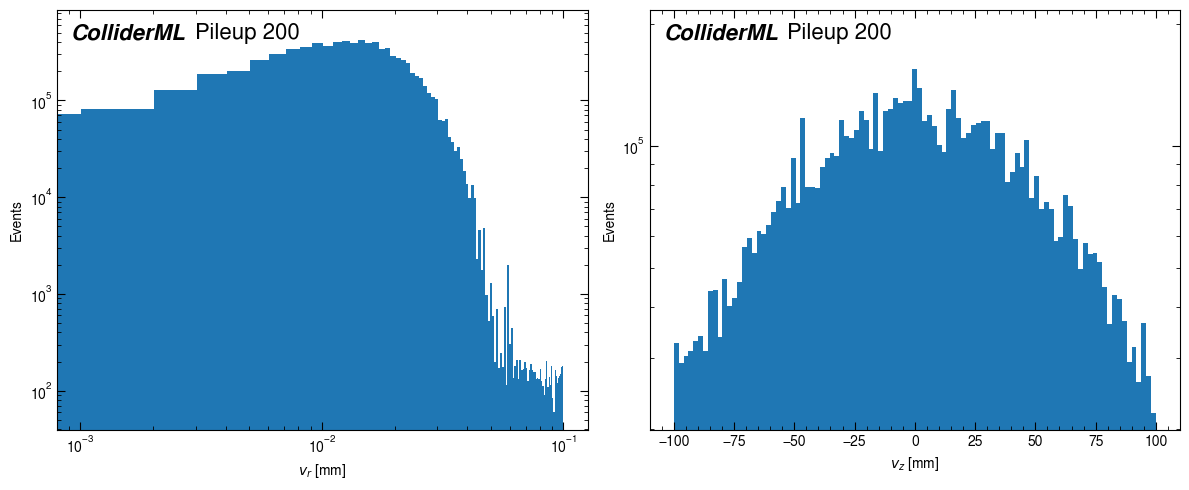

In [33]:
# Plot vr and vz distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Calculate vr from vx and vy
vr = np.sqrt(generator_particles["vx"]**2 + generator_particles["vy"]**2)

# Plot vr
bins_r = np.linspace(0, 0.1, 100)
counts_r = np.histogram(vr, bins=bins_r)[0]
axes[0].bar(bins_r[:-1], counts_r, width=bins_r[1]-bins_r[0], align='edge')
axes[0].set_xlabel("$v_r$ [mm]")
axes[0].set_ylabel("Events")
axes[0].set_yscale("log")
axes[0].set_xscale("log")
atl.atlasify("Pileup 200", axes=axes[0])

# Plot vz
bins_z = np.linspace(-100, 100, 100)
counts_z = np.histogram(generator_particles["vz"], bins=bins_z)[0]
axes[1].bar(bins_z[:-1], counts_z, width=bins_z[1]-bins_z[0], align='edge')
axes[1].set_xlabel("$v_z$ [mm]")
axes[1].set_ylabel("Events")
axes[1].set_yscale("log")
atl.atlasify("Pileup 200", axes=axes[1])

plt.tight_layout()
plt.show()


In [34]:
edm_input_file = "/global/cfs/cdirs/m4958/data/ColliderML/simulation/hard_scatter/ttbar/v1/runs/0/edm4hep.root"
hard_scatter_batch = EDM4hepEventBatch(edm_input_file, events=(0, 100), full_load=False)

In [35]:
hard_scatter_particles = hard_scatter_batch.get_particles_df()

In [36]:
hard_scatter_generator_particles = hard_scatter_particles[hard_scatter_particles["created_in_simulation"] == False]
hard_scatter_generator_particles

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,pz,parents_begin,parents_end,vr,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits
0,0,0,2212,0,1.000000,0.000000,0.93827,0.000000,0.000000,0.000000,...,6999.999937,0,0,0.000000,7000.000000,6999.061730,0,False,0,0
1,0,1,21,0,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,1210.616972,0,1,0.000000,1210.616972,1210.616972,1,False,0,0
2,0,2,2,0,0.666667,0.000000,0.33000,0.000000,0.000000,0.000000,...,3436.204368,1,2,0.000000,3436.204384,3435.874384,2,False,0,0
3,0,3,2103,0,0.333333,0.000000,0.77133,0.000000,0.000000,0.000000,...,2353.178474,2,3,0.000000,2353.178600,2352.407270,3,False,0,0
4,0,4,2212,0,1.000000,0.000000,0.93827,0.000000,0.000000,0.000000,...,-6999.999937,3,3,0.000000,7000.000000,6999.061730,4,False,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
593374,99,647,-211,33554432,-1.000000,2.009260,0.13957,-98.943449,-21.357873,-590.861208,...,-1.236491,1840,1841,101.222353,1.246787,1.107217,647,False,0,0
593375,99,648,321,16777216,1.000000,0.037956,0.49368,-1.487139,0.760332,-11.254144,...,-16.981106,1841,1842,1.670236,17.182459,16.688779,648,False,0,0
593376,99,649,-211,16777216,-1.000000,0.037956,0.13957,-1.487139,0.760332,-11.254144,...,-43.608413,1842,1843,1.670236,44.117088,43.977518,649,False,0,0
593377,99,650,-211,16777216,-1.000000,0.037956,0.13957,-1.487139,0.760332,-11.254144,...,-23.952669,1843,1844,1.670236,24.185029,24.045459,650,False,0,0


In [37]:
hard_scatter_generator_particles[hard_scatter_generator_particles.particle_id == 1]

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,pz,parents_begin,parents_end,vr,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits
1,0,1,21,0,0.000000,0.0,0.0,0.0,0.0,0.0,...,1210.616972,0,1,0.0,1210.616972,1210.616972,1,False,0,0
2225,1,1,3,0,-0.333333,0.0,0.0,0.0,0.0,0.0,...,159.195211,0,1,0.0,159.195211,159.195211,1,False,0,0
4950,2,1,21,0,0.000000,0.0,0.0,0.0,0.0,0.0,...,108.645622,0,1,0.0,108.645622,108.645622,1,False,0,0
8140,3,1,21,0,0.000000,0.0,0.0,0.0,0.0,0.0,...,326.818203,0,1,0.0,326.818203,326.818203,1,False,0,0
10286,4,1,21,0,0.000000,0.0,0.0,0.0,0.0,0.0,...,1195.934331,0,1,0.0,1195.934331,1195.934331,1,False,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558008,95,1,21,0,0.000000,0.0,0.0,0.0,0.0,0.0,...,4229.341612,0,1,0.0,4229.341612,4229.341612,1,False,0,0
562608,96,1,21,0,0.000000,0.0,0.0,0.0,0.0,0.0,...,2002.091746,0,1,0.0,2002.091746,2002.091746,1,False,0,0
568025,97,1,21,0,0.000000,0.0,0.0,0.0,0.0,0.0,...,1667.757959,0,1,0.0,1667.757959,1667.757959,1,False,0,0
584756,98,1,2,0,0.666667,0.0,0.0,0.0,0.0,0.0,...,3227.971778,0,1,0.0,3227.971778,3227.971778,1,False,0,0


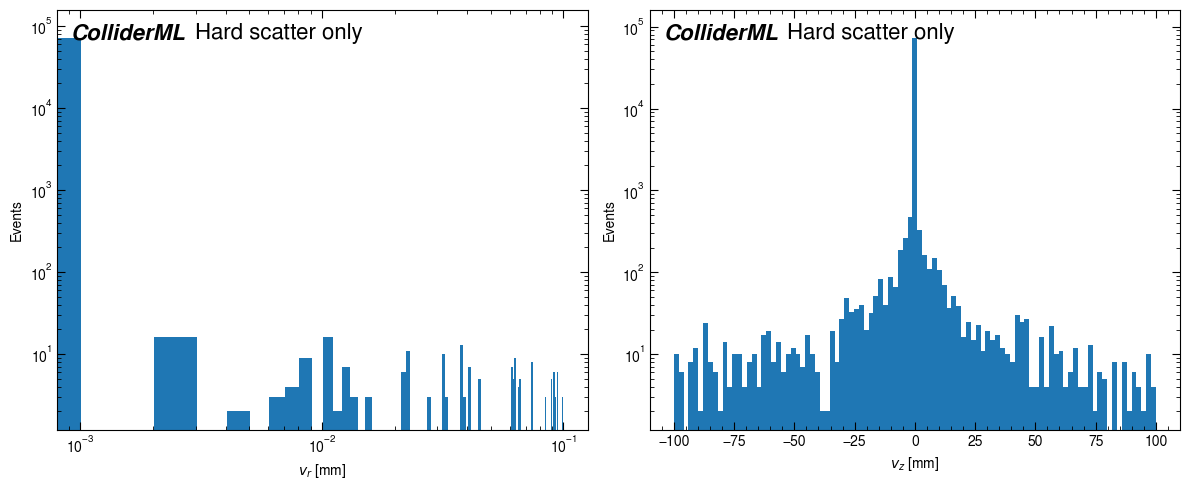

In [38]:
# Plot vr and vz distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Calculate vr from vx and vy
vr = np.sqrt(hard_scatter_generator_particles["vx"]**2 + hard_scatter_generator_particles["vy"]**2)

# Plot vr
bins_r = np.linspace(0, 0.1, 100)
counts_r = np.histogram(vr, bins=bins_r)[0]
axes[0].bar(bins_r[:-1], counts_r, width=bins_r[1]-bins_r[0], align='edge')
axes[0].set_xlabel("$v_r$ [mm]")
axes[0].set_ylabel("Events")
axes[0].set_yscale("log")
axes[0].set_xscale("log")
atl.atlasify("Hard scatter only", axes=axes[0])

# Plot vz
bins_z = np.linspace(-100, 100, 100)
counts_z = np.histogram(hard_scatter_generator_particles["vz"], bins=bins_z)[0]
axes[1].bar(bins_z[:-1], counts_z, width=bins_z[1]-bins_z[0], align='edge')
axes[1].set_xlabel("$v_z$ [mm]")
axes[1].set_ylabel("Events")
axes[1].set_yscale("log")
atl.atlasify("Hard scatter only", axes=axes[1])

plt.tight_layout()
plt.show()
